In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

In [ ]:
df = pd.read_csv("assets/datasets/breast-cancer.csv")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
print("=== QUANTIDADE DE DADOS EM BRANCO POR COLUNA ===")
vazios_por_coluna = df.isnull().sum()
print(vazios_por_coluna[vazios_por_coluna > 0]) 

if vazios_por_coluna.sum() == 0:
    print("Excelente! Nenhuma coluna possui dados em branco.")
else:
    print(f"\nTotal de células em branco no dataset: {vazios_por_coluna.sum()}")

print("\n" + "="*50 + "\n")

=== QUANTIDADE DE DADOS EM BRANCO POR COLUNA ===
Series([], dtype: int64)
Excelente! Nenhuma coluna possui dados em branco.




In [6]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis'].map({'M': 1, 'B': 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [7]:

parametros_mlp = {
    'hidden_layer_sizes': [(50,), (30, 15), (50, 25)],
    'activation': ['tanh', 'relu'],
    'solver': ['adam', 'sgd'],
    'max_iter': [500]
}

cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_mlp = GridSearchCV(
    MLPClassifier(random_state=42, early_stopping=True),
    parametros_mlp,
    cv=cv_folds,
    scoring='accuracy',
    n_jobs=-1
)
grid_mlp.fit(X_train_scaled, y_train)

melhor_mlp = grid_mlp.best_estimator_

print(f"-> Melhores parâmetros da Rede Neural: {grid_mlp.best_params_}\n")

-> Melhores parâmetros da Rede Neural: {'activation': 'tanh', 'hidden_layer_sizes': (50, 25), 'max_iter': 500, 'solver': 'adam'}



In [9]:
y_pred = melhor_mlp.predict(X_test_scaled)
y_probs = melhor_mlp.predict_proba(X_test_scaled)[:, 1]

print("=== MATRIZ DE CONFUSÃO ===")
print(confusion_matrix(y_test, y_pred))
print("\n" + "="*30)

print("\n=== RELATÓRIO DE CLASSIFICAÇÃO ===")
print(classification_report(y_test, y_pred, target_names=['Benigno (B)', 'Maligno (M)']))

=== MATRIZ DE CONFUSÃO ===
[[71  1]
 [ 3 39]]


=== RELATÓRIO DE CLASSIFICAÇÃO ===
              precision    recall  f1-score   support

 Benigno (B)       0.96      0.99      0.97        72
 Maligno (M)       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



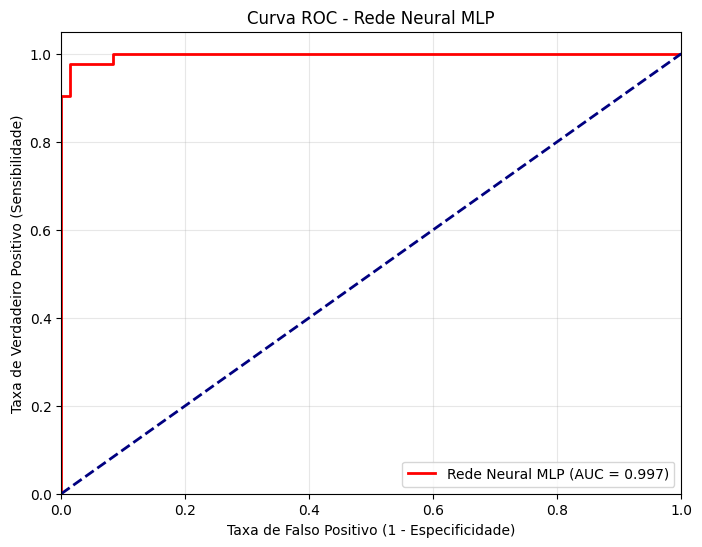

In [10]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='red', lw=2, label=f'Rede Neural MLP (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falso Positivo (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiro Positivo (Sensibilidade)')
plt.title('Curva ROC - Rede Neural MLP')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()